In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

np.random.seed(613)

In [2]:
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

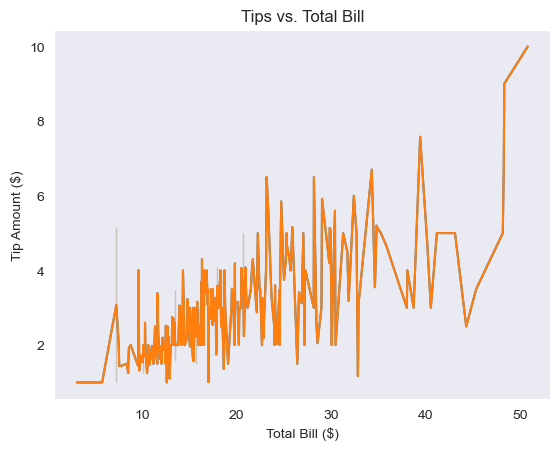

In [16]:
sns.lineplot(data=tips,
    x='total_bill',
    y='tip')

sns.set_style('dark')

tipgraph = sns.lineplot(data=tips,
                        x='total_bill',
                        y='tip')

tipgraph.set(
    title='Tips vs. Total Bill',
    xlabel='Total Bill ($)',
    ylabel='Tip Amount ($)'
)






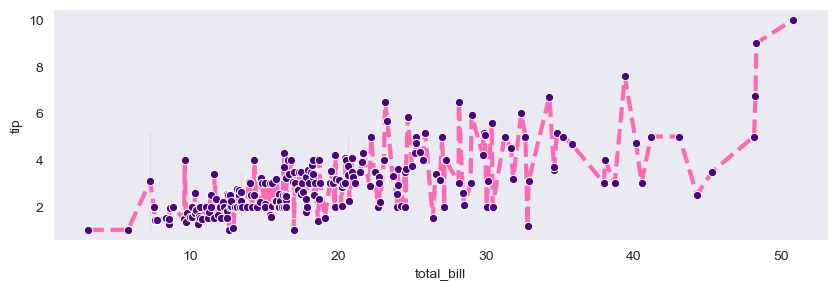

In [20]:
fig = plt.subplots(figsize=(10, 3))

tipgraph = sns.lineplot(
    data=tips,
    x='total_bill',
    y='tip',
    color='hotpink',
    linestyle='--',
    linewidth=3,
    marker='o',
    markerfacecolor='indigo'
)



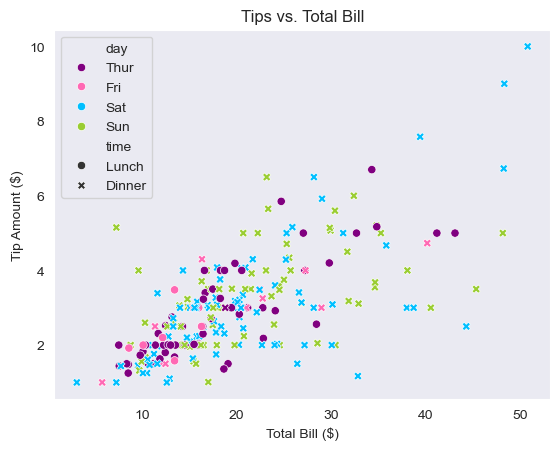

In [24]:


tipgraph = sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    style='time',
    hue='day',
    palette=['purple', 'hotpink', 'deepskyblue', 'yellowgreen']
)

tipgraph.set(
    title='Tips vs. Total Bill',
    xlabel='Total Bill ($)',
    ylabel='Tip Amount ($)'
)

plt.show()

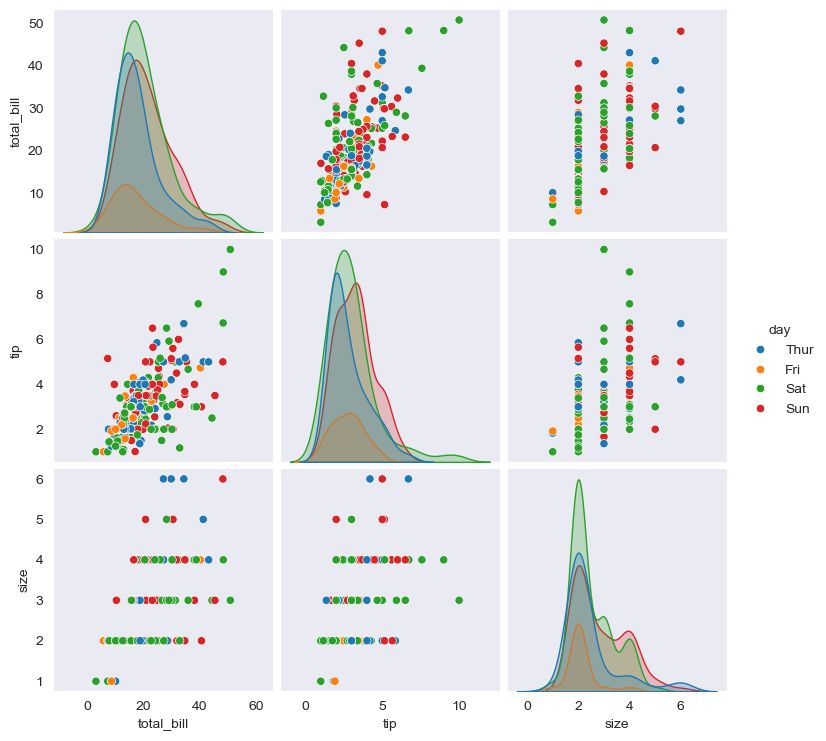

In [22]:
sns.pairplot(
data = tips,
hue = 'day')

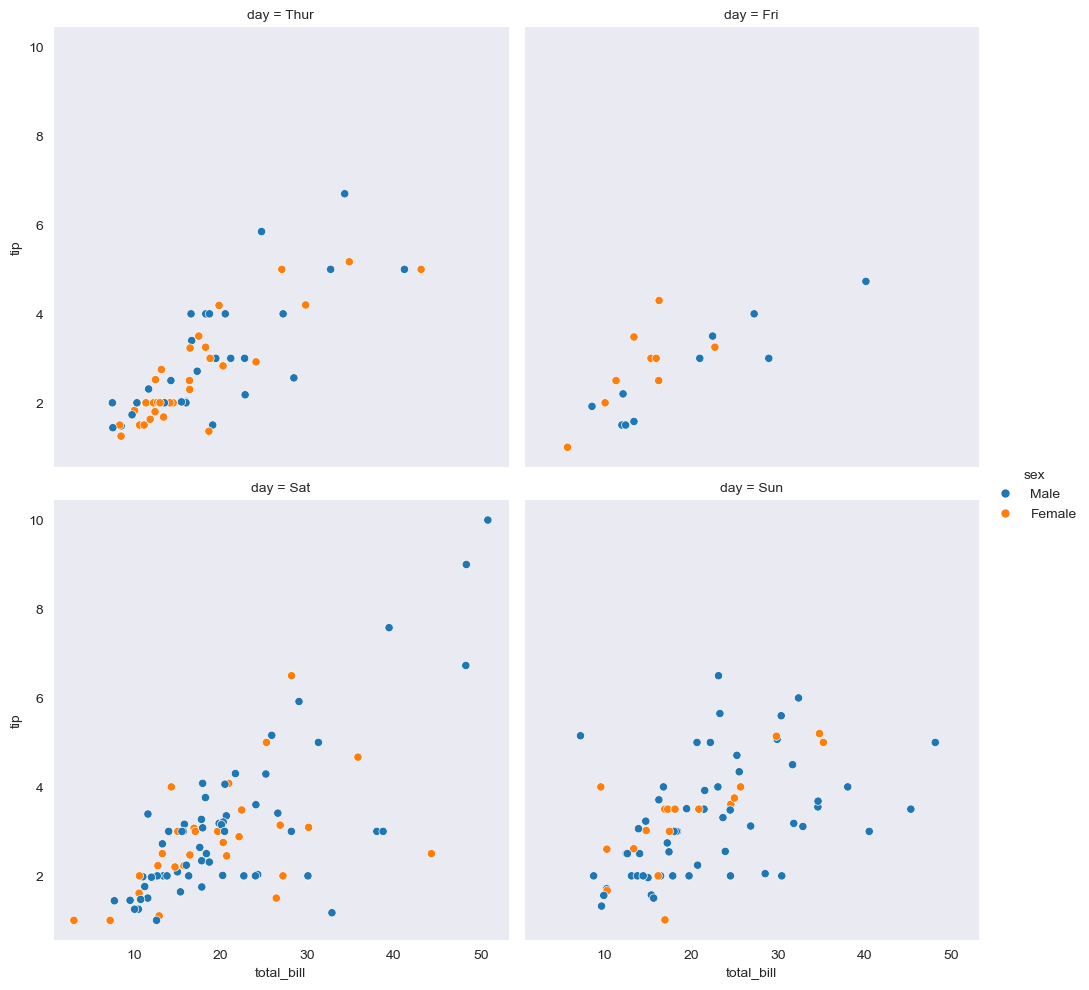

In [23]:

daysplot = sns.relplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="sex",
    col="day",
    kind="scatter",
    col_wrap=2
)

plt.show()

Activity: comparing data visualization
How are they different? What does each visualization ‘do’? static vs dynamic
What are the pros and cons of each? They both show gender bias but the first one is static and only able to show one aspect of the evaluations. 2nd one is dynamic and gives more details about evaluations.

Activity: type of changes
x and y axis (uses per millions words of text and discipline) stay same and data points change based on search terms. immidiate changes happening. 

In [33]:
import plotly.graph_objects as go

x1 = np.array(["Luffy",
"Zoro",
"Nami",
"Usopp",
"Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

graph = go.Figure()
graph.add_trace(go.Bar(x=x1, y=y1))

graph.update_layout(
title="Pirate Scores",
xaxis_title="Pirates",
yaxis_title="Score")

graph.show()



In [37]:

graph = go.Figure()


graph.add_trace(go.Scatter(
    x=x1,
    y=y1,
    mode='markers',
    marker=dict(
        size=15,              # point size
        color='hotpink',      # point color
        opacity=1,            # point transparency/alpha
        line=dict(width=5, color='purple')  # point outline
    )
))

# Update layout
graph.update_layout(
    title='Interactive Pirate Plot',
    xaxis=dict(title='Pirates'),
    yaxis=dict(title='Scores'),
    width=500,
    height=500
)

# Show plot
graph.show()

In [45]:
!pip install wordcloud


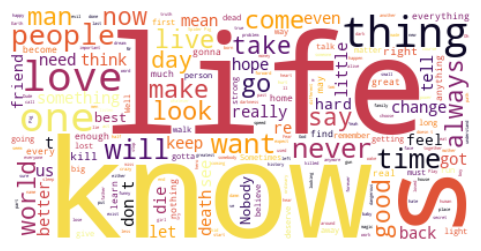

In [48]:
import pandas as pd
from wordcloud import WordCloud

# Read the CSV file
df = pd.read_csv(
    "https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
    on_bad_lines='skip'  # Skips malformed lines
)

# Display the DataFrame
df


# Join all the text from the quote column into a single string
text = " ".join(str(each) for each in df['quote'].dropna())

# Generate the word cloud
wordcloud = WordCloud(
    background_color='white',
    colormap='inferno'
).generate(text)

# Use matplotlib to display the word cloud
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis("off")  # Hide the axes

plt.show()




In [50]:
pip install matplotlib-venn


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=3009f66e3bfdc4fb0f4a5f7fad509431ab49c6114ce09aeeb9927f4eb29652cf
  Stored in directory: /Users/jerryluo/Library/Caches/pip/wheels/86/29/d8/0f3c5a37c967a34fb40aaabd414f92104d2ad5fb149c0114a1
Successfully built matplotlib-venn
Note: you may need to restart the kernel to use updated packages.


AttributeError: 'NoneType' object has no attribute 'set_text'

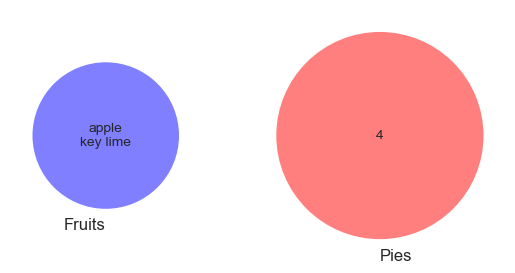

In [59]:
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

A = set([
    "apple",
    "apple",
    "key lime"
])

B = set([
    "pumpkin",
    "banana",
    "blueberry",
    "watermelon"
])

diagram = venn2(
    [A, B], 
    set_labels=('Fruits', 'Pies'),
    set_colors=('blue', 'red'),
    alpha=0.5
)

# Update subset labels with actual set elements
diagram.get_label_by_id("10").set_text("\n".join(A - B))
diagram.get_label_by_id("11").set_text("\n".join(A & B))  # intersection is empty here
diagram.get_label_by_id("01").set_text("\n".join(B - A))



